# Phase 1 — Baseline (régression linéaire / forêt aléatoire) sur FD001

Objectif : entraîner deux modèles classiques (sans mémoire séquentielle) sur des features
agrégées par fenêtre, pour avoir un point de comparaison avant le LSTM/GRU (test H1 du
protocole : le deep learning apporte-t-il un gain mesurable ?).

Critère « fait » (plan d'exécution, Phase 1) : scores RMSE + asymétrique sur le val.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    aggregate_window_features,
    compute_norm_stats,
    make_windows,
    normalize,
    select_features,
    split_by_unit,
)

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES
raw.shape

(20631, 26)

In [2]:
train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)

print("Moteurs train :", train_raw["unit_number"].nunique())
print("Moteurs val   :", val_raw["unit_number"].nunique())
assert set(train_raw["unit_number"]).isdisjoint(val_raw["unit_number"])

Moteurs train : 80
Moteurs val   : 20


In [3]:
selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

train_norm = normalize(train_raw, selected_sensors, norm_stats)
val_norm = normalize(val_raw, selected_sensors, norm_stats)  # mêmes stats que le train, jamais recalculées sur val

len(selected_sensors)

14

In [4]:
train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)  # val vient aussi de train_FD001.txt : cycle de vie complet connu

# On garde toutes les fenêtres glissantes (last_only=False) pour le train ET le val, car les
# deux ont des séquences complètes jusqu'à la panne : contrairement au vrai test, on peut se
# permettre plusieurs fenêtres par moteur en val, ce qui donne une estimation plus stable.
X_train_win, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_val_win, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

X_train_win.shape, X_val_win.shape

((14459, 30, 14), (3272, 30, 14))

In [5]:
X_train = aggregate_window_features(X_train_win)
X_val = aggregate_window_features(X_val_win)

models = {
    "Régression linéaire": LinearRegression(),
    "Forêt aléatoire": RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    predictions[name] = y_pred
    results.append({
        "modèle": name,
        "RMSE": rmse(y_val, y_pred),
        "score_asymétrique": asymmetric_score(y_val, y_pred),
    })

results_df = pd.DataFrame(results)
results_df

,modèle,RMSE,score_asymétrique
0,Régression linéaire,21.536573,77665.928021
1,Forêt aléatoire,17.899715,29640.942003


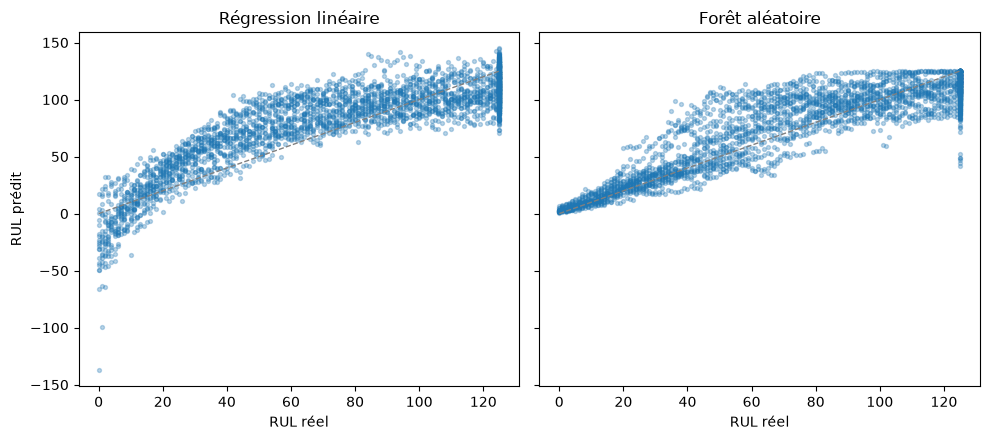

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_val, y_pred, s=8, alpha=0.3)
    ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("RUL réel")

axes[0].set_ylabel("RUL prédit")
fig.tight_layout()

**Ce que montre cette figure** : chaque point est une fenêtre de validation, sa position
horizontale est son vrai RUL, sa position verticale la prédiction du modèle. La ligne
pointillée est la diagonale "prédiction parfaite" (`y_pred = y_true`) : plus les points sont
proches de cette ligne, meilleur est le modèle. On s'attend à voir un "aplatissement" près du
plafond 125 (à droite) : c'est normal, beaucoup de fenêtres en tout début de vie ont toutes le
même RUL cible (125), donc les prédictions s'y concentrent aussi sans qu'on puisse distinguer
ces fenêtres entre elles. Si un des deux modèles montre plus de dispersion verticale (surtout
à gauche, RUL faible = proche de la panne), c'est lui qui rate le plus de pannes imminentes —
la partie qui compte le plus vu le score asymétrique.